In [3]:
%pip install tensorflow_datasets importlib_resources

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [14]:
(train_ds), info = tfds.load('citrus_leaves', split='train',with_info=True, as_supervised=True)
class_name = info.features['label'].names

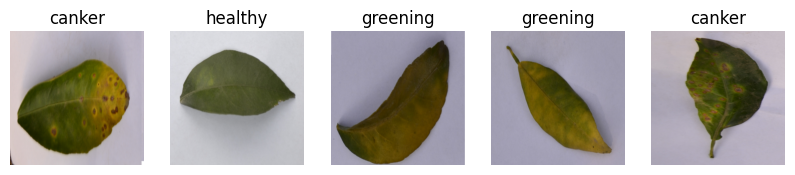

In [17]:
plt.figure(figsize=(10,2))
for i, (img, lbl) in enumerate(train_ds.take(5)):
    plt.subplot(1,5,i+1)
    plt.imshow(img.numpy().astype('uint8'))
    plt.title(class_name[lbl.numpy()])
    plt.axis('off')
plt.show()

In [18]:
DATASET_SIZE = info.splits['train'].num_examples
train_size = int(0.8*DATASET_SIZE)
test_size = DATASET_SIZE - train_size

In [20]:
train_ds_raw = train_ds.take(train_size)
test_ds_raw = train_ds.skip(train_size)

In [19]:
def preprocess(image, label):
    image = tf.image.resize(image,(128,128))/255.0
    return image, label

In [21]:
train_data = train_ds_raw.map(preprocess).batch(32)
test_data = test_ds_raw.map(preprocess).batch(32)

In [23]:
model = Sequential([
    Conv2D(32,activation='relu',kernel_size=(3,3),input_shape = (128,128,3)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(4,activation='softmax')
])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [26]:
model.fit(train_data,epochs = 50)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.4324 - loss: 6.7284
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6647 - loss: 2.5207
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.6412 - loss: 0.7541
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8000 - loss: 0.4912
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9118 - loss: 0.3210
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9206 - loss: 0.2376
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9618 - loss: 0.1751
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9706 - loss: 0.1362
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9912 - loss: 0.0872
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9882 - loss: 0.0845
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.9971 - loss: 0.0559
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy:

In [28]:
y_true = np.concatenate([y for x,y in test_data], axis = 0)

In [29]:
y_pred = np.argmax(model.predict(test_data),axis = 1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [30]:
accuracy_score(y_true,y_pred)

0.9176470588235294

In [31]:
cm = confusion_matrix(y_true,y_pred)

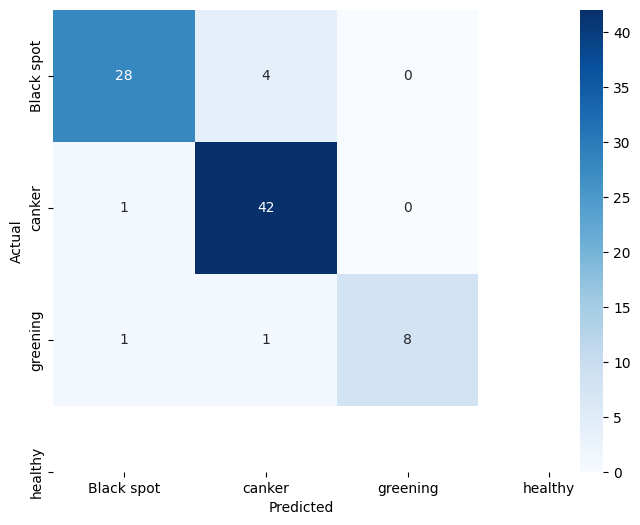

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_name, yticklabels=class_name)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()